In [6]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid', font_scale=1.3, palette='Set2')

import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
import statsmodels.datasets as smd
import statsmodels.api as sm

## Статистические свойства линейной регрессии

Загрузим датасет с данными по стоимости квартир в Москве (<a href="https://raw.githubusercontent.com/bdemeshev/em301/master/datasets/flats_moscow.txt">источник</a>).

In [7]:
flats = pd.read_csv("data/flats_moscow.txt", sep='\t')
flats.head()

,n,price,totsp,livesp,kitsp,dist,metrdist,walk,brick,floor,code
0,1,81,58,40,6.0,12.5,7,1,1,1,3
1,2,75,44,28,6.0,13.5,7,1,0,1,6
2,3,128,70,42,6.0,14.5,3,1,1,1,3
3,4,95,61,37,6.0,13.5,7,1,0,1,1
4,5,330,104,60,11.0,10.5,7,0,1,1,3


Будем рассматривать зависимость цены квартиры от ее площади. По графику явно видна гетероскедастичность.

*Примечание. Строго говоря, такой проверки недостаточно, стоит проверять зависимость остатков, а не таргета. Если хотя бы по одному признаку видна разная дисперсия остатков, то имеет смысл говорить о гетероскедастичности.*

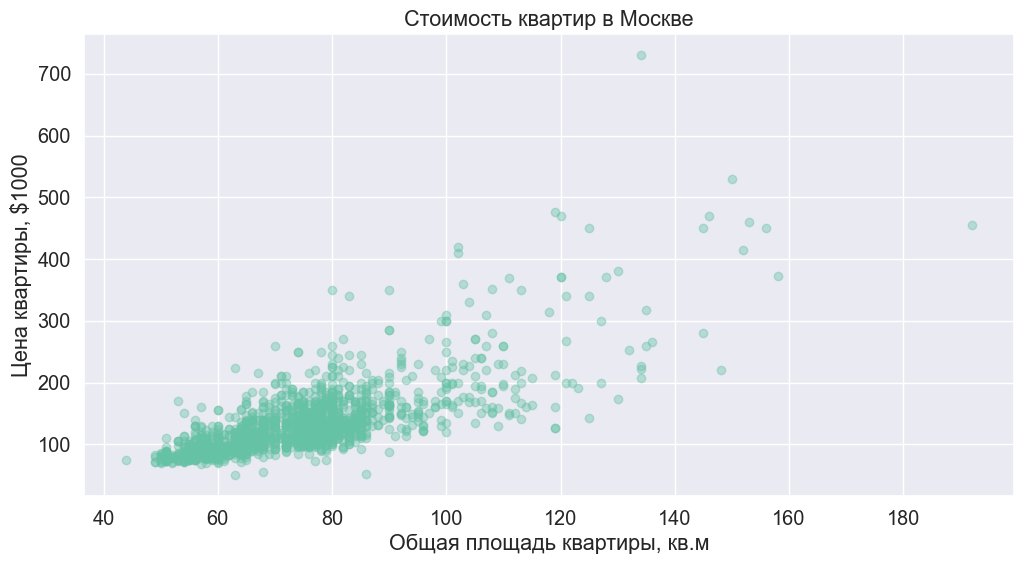

In [8]:
plt.figure(figsize=(12, 6))
plt.scatter(flats['totsp'], flats['price'], alpha=0.4)
plt.title('Стоимость квартир в Москве')
plt.xlabel('Общая площадь квартиры, кв.м')
plt.ylabel('Цена квартиры, $1000');

### 1. Обучение простой линейной модели

Сначала обучим линейную регрессию, для этого воспользуемся реализацией `statsmodels.regression.linear_model.OLS(Y, X)`

Модель можно задавать двумя способами:
* как обычно передав таргет и матрицу признаков
* указав формулу в виде `target ~ features`, которая означает линейную функцию `target` от `features`

In [9]:
linear = smf.ols('price ~ totsp', flats)
l_results = linear.fit()

Метод `fit` возвращает объект типа `statsmodels.regression.linear_model.RegressionResults`, который содержит различные характеристики модели:
* в первой секции представлены различные характеристики самой модели
    * параметры обучения,
    * $R^2$
    * Проверка гипотезы о значимости регрессии в целом
    * логарифмическая функция правдоподобия
    * информационные критерии
* во второй секции &mdash; подробная информация о коэффициентов, включая анализ их стат. значимости:
    * названия коэффициентов (совпадают с именами признаков, или `Intercept` для свободного коэффициента);
    * оценки коэффициентов;
    * стандартные ошибки &mdash; корень из оценки дисперсии оценки каждого из коэффициентов;
    * t-статистика для проверки гипотезы о незначимости коэффициента;
    * p-value критерия для проверки гипотезы о незначимости коэффициента (правило: если $\text{p-value} \leqslant \alpha=0.05$, то гипотеза отвергается, иначе &mdash; не отвергается);
    * левая и правая граница 95\% доверительного интервала для коэффициента.
* в третьей секции &mdash; анализ остатков модели
    * критерии проверки несмещенности, нормальности

*Подробнее:* https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.RegressionResults.html

Посмотрим на результат **в предположении гомоскедастичности**

In [10]:
print(l_results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     2719.
Date:                Sun, 27 Oct 2024   Prob (F-statistic):               0.00
Time:                        20:34:48   Log-Likelihood:                -10085.
No. Observations:                2040   AIC:                         2.017e+04
Df Residuals:                    2038   BIC:                         2.019e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -62.0448      3.712    -16.716      0.0

Можно извлечь результаты отдельных тестов, например, проверка гипотезы о незначимости коэффициента перед признаком `totsp`

In [9]:
result = l_results.t_test('totsp = 0')
result

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.5935      0.050     52.146      0.000       2.496       2.691

Можно извлечь отдельные числа

In [10]:
result.pvalue

array(0.)

In [11]:
result.conf_int()

array([[2.49592664, 2.69099796]])

Посмотрим на ковариационную матрицу вектора $\widehat{\theta}$ **в условиях гомоскедастичности**, что в данном случае не выполнено.

In [12]:
l_results.cov_params()

,Intercept,totsp
Intercept,13.777292,-0.180775
totsp,-0.180775,0.002474


У нас явная гетероскедастичность, проверим это критериями

### 2. Проверка на гетероскедастичность

*При наличии подозрений на гетероскедастичность рекомендуется сразу использовать устойчивые оценки дисперсии (см. далее), не применяя проверку на гетероскедастичность стат. критериями. Данные критерии также имеют свои ошибки, и последовательное применение нескольких критериев может суммировать вероятности ошибок.*

**Критерий Бройша-Пагана**

In [13]:
test = sms.het_breuschpagan(l_results.resid, l_results.model.exog)

name = ["Lagrange multiplier statistic", "p-value", "f-value", "f p-value"]
pd.Series(test, index=name)

Lagrange multiplier statistic    2.019538e+02
p-value                          7.824949e-46
f-value                          2.239235e+02
f p-value                        4.107852e-48
dtype: float64

**Критерий Голдфелда-Квандта**

In [14]:
test = sms.het_goldfeldquandt(l_results.resid, l_results.model.exog)

name = ["F statistic", "p-value", "type"]
pd.Series(test, index=name)

F statistic      0.827954
p-value          0.998689
type           increasing
dtype: object

**Критерий Уайта**

In [15]:
test = sms.het_white(l_results.resid, l_results.model.exog)

name = ["Lagrange multiplier statistic", "p-value", "f-value", "f p-value"]
pd.Series(test, index=name)

Lagrange multiplier statistic    2.473515e+02
p-value                          1.942238e-54
f-value                          1.405337e+02
f p-value                        6.706169e-58
dtype: float64

### 3. Использование устойчивых оценок дисперсии

Правильную оценку ковариационной матрицы вектора $\widehat{\theta}$ в условиях гетероскедастичности позволяет получить функция `get_robustcov_results`. Возможные следующие виды оценок:
* `"fixed scale"`,
* `"HC0"`,
* `"HC1"` (по умолчанию),
* `"HC2"`,
* `"HC3"`,
* `"HAC"`,
* `"cluster"`,
* `"hac-groupsum"`,
* `"hac-panel"`

Возьмем `cov_type="HC3"` и посмотрим на результат. Интерпретация значений в таблицах аналогична, см. пояснения выше. Можно также заметить, что изменились статистические свойства оценок коэффициентов, при этом сами оценки коэффициентов не поменялись.

In [16]:
robust_results = l_results.get_robustcov_results(cov_type="HC3")
print(robust_results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                     516.0
Date:                Sun, 27 Oct 2024   Prob (F-statistic):          5.24e-102
Time:                        20:05:24   Log-Likelihood:                -10085.
No. Observations:                2040   AIC:                         2.017e+04
Df Residuals:                    2038   BIC:                         2.019e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -62.0448      7.859     -7.895      0.0

Посмотрим матрицу ковариации, к сожалению названия параметров теряются.

In [17]:
pd.DataFrame(
    robust_results.cov_params(), 
    index=l_results.params.index, 
    columns=l_results.params.index
)

,Intercept,totsp
Intercept,61.766292,-0.895030
totsp,-0.895030,0.013036


In [18]:
linear.fit(cov_type='HC3').cov_params()

,Intercept,totsp
Intercept,61.766292,-0.895030
totsp,-0.895030,0.013036


### 4. Пример с несколькими признаками

Рассмотрим регрессию, задаваемую формулой `price ~ totsp + livesp + dist`, указав тип используемой оценки матрицы ковариаций в предположении гетероскедастичности. Такая формула означает модель
$$price = \theta_0 + \theta_1 \cdot totsp + \theta_2 \cdot livesp + \theta_3 \cdot dist$$

*Подробнее про синтаксис формул: https://www.statsmodels.org/stable/example_formulas.html*

*Можно также использовать более привычный формат: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html (обратите внимание, сначала нужно передать таргет, а потом фичи)*

Посмотрим на сводку по модели.

In [19]:
model2 = smf.ols('price ~ totsp + livesp + dist', flats)
results2 = model2.fit(cov_type='HC3')
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.644
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     356.3
Date:                Sun, 27 Oct 2024   Prob (F-statistic):          5.54e-186
Time:                        20:05:24   Log-Likelihood:                -9896.8
No. Observations:                2040   AIC:                         1.980e+04
Df Residuals:                    2036   BIC:                         1.982e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -36.2647     13.514     -2.683      0.0

Как и раньше, можно извлечь результаты отдельных тестов

In [20]:
results2.t_test('totsp = 0')

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.8651      0.175     10.657      0.000       1.522       2.208

С помощью t-критерия можно проверять одну любую линейную гипотезу. Например, гипотеза о равенстве $\theta_{totsp} = 2\theta_{dist}$.

In [21]:
results2.t_test('totsp = 2*dist')

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             8.8294      0.542     16.278      0.000       7.766       9.893

Можно использовать  f-критерий для проверки нескольких линейных гипотез. 

Например, проверим гипотезу об одновременной незначимости коэффициентов перед признаками `livesp`, `dist`.

In [22]:
print(results2.f_test("(livesp=0), (dist=0)"))

<F test: F=158.27856958580404, p=1.281946563979747e-64, df_denom=2.04e+03, df_num=2>


Можно проверить гипотезу о равенстве $\theta_{totsp} = \theta_{dist}$.

In [23]:
print(results2.f_test("(livesp=dist)"))

<F test: F=122.08370500666014, p=1.3242745966324093e-27, df_denom=2.04e+03, df_num=1>


## Обобщенная линейная модель

Ожидаемый отклик $\large{y = \mu_\theta(x)}$, где $\large{g(\mu_\theta(x))=x^T\theta}.$

Наблюдаемый отклик $\large{Y_i \sim \mathsf{P}_{\mu_\theta(x_i)}}$.

Оценка ожидаемого отклика $\large{\widehat{y}} = g^{-1}\left(x^T\widehat{\theta}\right)$.

<a href="https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.html">Документация</a>

Синтаксис:
> `model = GLM(y_train, X_train, family=sm.family.Gaussian())`

*Методы класса*:
* `reg.fit(X=X_train)` &mdash; возвращает объект типа `statsmodels.base.model.LikelihoodModelResults`

*Аргументы*:
* `X_train`, `Y_train` &mdash; выборка;
* `family` &mdash; семейство распределений из <a href="https://www.statsmodels.org/stable/glm.html#families">Списка</a>.

Как и для простой линейной модели glm можно задавать двумя способами:
* как обычно передав таргет и матрицу признаков (единичного признака нет).
* указав формулу в виде `target ~ features`, которая означает линейную функцию `target` от `features` (единичный признак есть).

### Логистическая регрессия

В качестве линеризации ожидаемого отклика рассматриваем логит-функцию, а наблюдаемый отклик распределен из $Bern(\mu_\theta(x)),$ где $\large{\mu_\theta(x) = \cfrac{1}{1 + e^{x^T\theta}}}$.

---

Возьмем <a href="https://vincentarelbundock.github.io/Rdatasets/doc/MASS/biopsy.html">датасет</a> о раке груди в котором по ряду признаков нужно оценить доброкачественная или злокачественная опухоль.

In [11]:
cancer = smd.get_rdataset("biopsy", package="MASS").data
cancer = cancer.set_index(["ID"])
cancer.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,class
ID,,,,,,,,,,
1000025,5,1,1,1,2,1.0,3,1,1,benign
1002945,5,4,4,5,7,10.0,3,2,1,benign
1015425,3,1,1,1,2,2.0,3,1,1,benign
1016277,6,8,8,1,3,4.0,3,7,1,benign
1017023,4,1,1,3,2,1.0,3,1,1,benign


In [25]:
cancer = cancer.dropna()
cancer.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


Приведем класс к числовому

In [26]:
cancer['y'] = (cancer['class'] == 'benign') * 1
cancer = cancer.drop(["class"], axis=1)
cancer.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,y
ID,,,,,,,,,,
1000025,5,1,1,1,2,1.0,3,1,1,1
1002945,5,4,4,5,7,10.0,3,2,1,1
1015425,3,1,1,1,2,2.0,3,1,1,1
1016277,6,8,8,1,3,4.0,3,7,1,1
1017023,4,1,1,3,2,1.0,3,1,1,1


Определим модель &mdash; линейную комбинацию всех признаков. Обучим GLM, используя биномиальное семейство (`sm.families.Binomial`), что соответствует логистической регрессии.

In [27]:
all_params = "+".join(cancer.columns.difference(["y"]))
glm_model = smf.glm("y ~ " + all_params, cancer, family=sm.families.Binomial())
glm_results = glm_model.fit()

Посмотрим статистические свойства обученной модели. Интерпретация таблицы аналогична таблице в простой линейной регрессии, см. выше.

In [28]:
print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  683
Model:                            GLM   Df Residuals:                      673
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -51.444
Date:                Sun, 27 Oct 2024   Deviance:                       102.89
Time:                        20:05:26   Pearson chi2:                     592.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6815
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.1039      1.175      8.600      0.0